In [37]:
from pathlib import Path
import os
import random
import json
import math
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image, ImageOps

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

try:
    import tifffile
except ImportError:
    tifffile = None

try:
    import mrcfile
except ImportError:
    mrcfile = None

print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("gpu:", torch.cuda.get_device_name(0))

torch: 2.6.0+cu124
cuda available: True
gpu: NVIDIA GeForce RTX 4090


In [38]:
#Settings 
DATA_DIR = Path("../data") 
OUTPUT_DIR = Path("../outputs/image_classifier")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CLASS_NAMES = ["Atlas", "Square", "Protein", "Other"]
CLASS_TO_IDX = {name: i for i, name in enumerate(CLASS_NAMES)}
IDX_TO_CLASS = {i: name for name, i in CLASS_TO_IDX.items()}

IMAGE_EXTENSIONS = {".png", ".jpg", ".jpeg", ".tif", ".tiff", ".mrc"}

IMAGE_SIZE = 224
BATCH_SIZE = 32
NUM_WORKERS = 2 
SEED = 42

HEAD_EPOCHS = 5          
FINETUNE_EPOCHS = 10     
HEAD_LR = 1e-3
FINETUNE_LR = 1e-4
WEIGHT_DECAY = 1e-4

USE_PRETRAINED = True

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [39]:
def read_raw_image(path):
    """
    Read PNG/JPG/TIFF/MRC as a 2D float32 numpy array.
    For MRC stacks/volumes, this prototype uses the first slice.
    """
    path = Path(path)
    suffix = path.suffix.lower()

    if suffix == ".mrc":
        if mrcfile is None:
            raise ImportError("mrcfile is not installed")
        with mrcfile.open(path, permissive=True) as mrc:
            arr = np.asarray(mrc.data)
        arr = np.squeeze(arr)
        if arr.ndim == 3:
            arr = arr[0]

    elif suffix in {".tif", ".tiff"}:
        if tifffile is None:
            raise ImportError("tifffile is not installed")
        arr = tifffile.imread(path)
        arr = np.asarray(arr)
        arr = np.squeeze(arr)
        if arr.ndim == 3:
            # If RGB/RGBA, convert with PIL. Otherwise treat as stack and use first slice.
            if arr.shape[-1] in (3, 4):
                arr = np.asarray(Image.fromarray(arr).convert("L"))
            else:
                arr = arr[0]

    else:
        arr = np.asarray(Image.open(path).convert("L"))

    arr = np.asarray(arr, dtype=np.float32)
    arr = np.squeeze(arr)

    if arr.ndim != 2:
        raise ValueError(f"Expected a 2D image after loading, got shape {arr.shape} for {path}")

    return arr


def normalize_to_uint8(arr, low_pct=1, high_pct=99):
    """
    Percentile clip + scale to uint8.
    This makes brightness/contrast more consistent across cryo-EM screenshots.
    """
    arr = np.asarray(arr, dtype=np.float32)
    finite = np.isfinite(arr)
    if not np.any(finite):
        raise ValueError("Image contains no finite pixel values.")

    arr = arr.copy()
    arr[~finite] = np.nanmedian(arr[finite])

    lo, hi = np.percentile(arr, [low_pct, high_pct])
    if hi <= lo:
        hi = lo + 1.0

    arr = np.clip(arr, lo, hi)
    arr = (arr - lo) / (hi - lo)
    arr = (arr * 255).astype(np.uint8)
    return arr


def read_cryo_pil(path):
    """
    Returns a normalized grayscale image duplicated into RGB channels.
    ResNet expects 3 input channels.
    """
    raw = read_raw_image(path)
    img_u8 = normalize_to_uint8(raw)
    return Image.fromarray(img_u8, mode="L").convert("RGB")

In [40]:
class SquarePadResize:
    """
    Resize while preserving aspect ratio, then pad to a square.
    This matches the prototype goal of standardizing images to 224 x 224
    without badly stretching atlas/square/protein shapes.
    """
    def __init__(self, size=224, fill=0):
        self.size = size
        self.fill = fill

    def __call__(self, img):
        img = img.copy()
        img.thumbnail((self.size, self.size), Image.Resampling.BILINEAR)
        canvas = Image.new("RGB", (self.size, self.size), (self.fill, self.fill, self.fill))
        x = (self.size - img.width) // 2
        y = (self.size - img.height) // 2
        canvas.paste(img, (x, y))
        return canvas


imagenet_mean = [0.485, 0.456, 0.406]
imagenet_std = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.5),
    T.RandomRotation(degrees=10, fill=0),
    T.RandomApply([T.ColorJitter(brightness=0.15, contrast=0.15)], p=0.5),
    SquarePadResize(IMAGE_SIZE, fill=0),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])

eval_transform = T.Compose([
    SquarePadResize(IMAGE_SIZE, fill=0),
    T.ToTensor(),
    T.Normalize(mean=imagenet_mean, std=imagenet_std),
])

In [41]:
def build_manifest(data_dir=DATA_DIR, class_names=CLASS_NAMES):
    """
    Builds a dataframe with columns:
    - path
    - label
    - label_idx

    Expected folder structure:
        data_dir/
            Atlas_All/
            Square_All/
            Protein_All/
            Other_All/
    """
    rows = []
    data_dir = Path(data_dir)

    if not data_dir.exists():
        raise FileNotFoundError(f"Data directory does not exist: {data_dir}")

    # Allows folder matching to ignore capitalization on Linux.
    directory_lookup = {
        path.name.lower(): path
        for path in data_dir.iterdir()
        if path.is_dir()
    }

    for class_name in class_names:
        expected_folder_name = f"{class_name}_All"

        # For example, "atlas_All" will match "Atlas_All".
        class_dir = directory_lookup.get(expected_folder_name.lower())

        if class_dir is None:
            warnings.warn(
                f"Missing expected class folder: "
                f"{data_dir / expected_folder_name}"
            )
            continue

        for path in class_dir.rglob("*"):
            if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
                rows.append({
                    "path": str(path),
                    "label": class_name,
                    "label_idx": CLASS_TO_IDX[class_name],
                })

    df = pd.DataFrame(rows)

    if df.empty:
        expected_folders = ", ".join(
            f"{class_name.capitalize()}_All"
            for class_name in class_names
        )

        raise FileNotFoundError(
            f"No supported images found under {data_dir}. "
            f"Expected folders such as: {expected_folders}"
        )

    return df.sample(
        frac=1,
        random_state=SEED
    ).reset_index(drop=True)


df = build_manifest(DATA_DIR)

print("Images found per class:")
print(df["label"].value_counts())

df.head()

Images found per class:
label
Square     325
Protein    201
Other      200
Atlas      155
Name: count, dtype: int64


,path,label,label_idx
0,../data/Square_All/GridSquare_20260113_121025.jpg,Square,1
1,../data/Square_All/GridSquare_20260317_211612.jpg,Square,1
2,../data/Protein_All/012975808391444339571_Foil...,Protein,2
3,../data/Other_All/26542-Ph_golgi__cdp2w7x2_e12...,Other,3
4,../data/Square_All/GridSquare_20260219_114206.jpg,Square,1


In [42]:
def make_splits(df, test_size=0.15, val_size=0.15, seed=SEED):
    """
    Creates train/val/test splits.

    Uses stratified splitting when each class has enough images.
    Falls back to random splitting for very tiny prototype datasets.
    """
    counts = df["label"].value_counts()
    can_stratify = (counts.min() >= 3) and (len(counts) == len(CLASS_NAMES))

    stratify_y = df["label"] if can_stratify else None
    if not can_stratify:
        print("Warning: tiny or incomplete dataset. Using random split instead of stratified split.")

    train_val_df, test_df = train_test_split(
        df,
        test_size=test_size,
        random_state=seed,
        stratify=stratify_y,
    )

    relative_val_size = val_size / (1.0 - test_size)
    stratify_train_val = train_val_df["label"] if can_stratify else None

    train_df, val_df = train_test_split(
        train_val_df,
        test_size=relative_val_size,
        random_state=seed,
        stratify=stratify_train_val,
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


train_df, val_df, test_df = make_splits(df)

print("train:", len(train_df), train_df["label"].value_counts().to_dict())
print("val:  ", len(val_df), val_df["label"].value_counts().to_dict())
print("test: ", len(test_df), test_df["label"].value_counts().to_dict())

train_df.to_csv(OUTPUT_DIR / "train_manifest.csv", index=False)
val_df.to_csv(OUTPUT_DIR / "val_manifest.csv", index=False)
test_df.to_csv(OUTPUT_DIR / "test_manifest.csv", index=False)

train: 616 {'Square': 227, 'Protein': 141, 'Other': 140, 'Atlas': 108}
val:   132 {'Square': 49, 'Other': 30, 'Protein': 30, 'Atlas': 23}
test:  133 {'Square': 49, 'Other': 30, 'Protein': 30, 'Atlas': 24}


In [43]:
class CryoImageDataset(Dataset):
    def __init__(self, dataframe, transform):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = read_cryo_pil(row["path"])
        img = self.transform(img)
        label = int(row["label_idx"])
        return img, label, row["path"]


train_ds = CryoImageDataset(train_df, train_transform)
val_ds = CryoImageDataset(val_df, eval_transform)
test_ds = CryoImageDataset(test_df, eval_transform)

# Weighted sampling helps if you have many more atlas images than square/protein/other images.
class_counts = train_df["label_idx"].value_counts().to_dict()
sample_weights = train_df["label_idx"].map(lambda x: 1.0 / class_counts[x]).values
sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

pin_memory = torch.cuda.is_available()

train_loader = DataLoader(
    train_ds,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

val_loader = DataLoader(
    val_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

test_loader = DataLoader(
    test_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=pin_memory,
)

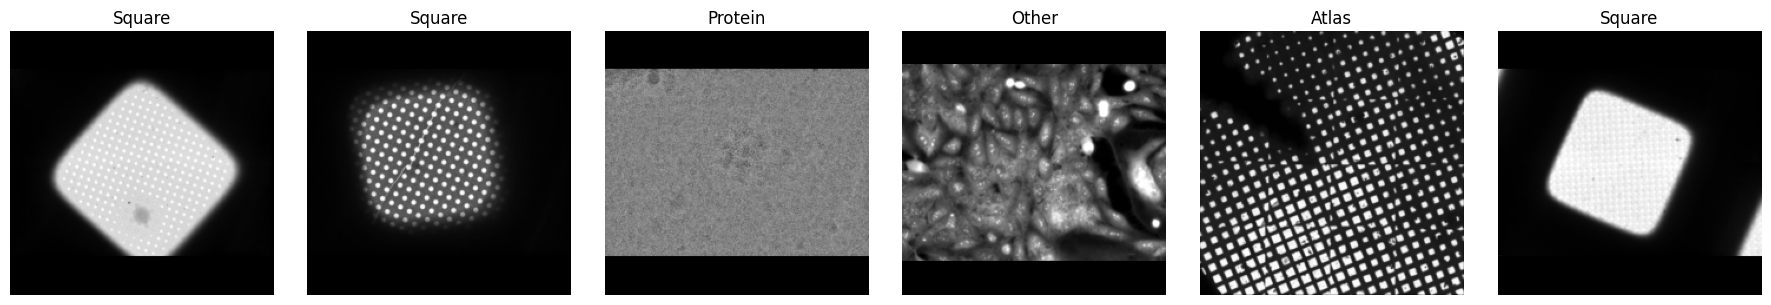

In [44]:
def show_batch(dataset, n=8):
    n = min(n, len(dataset))
    indices = random.sample(range(len(dataset)), n)
    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))

    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, indices):
        path = dataset.df.iloc[idx]["path"]
        label = dataset.df.iloc[idx]["label"]
        img = read_cryo_pil(path)
        img = SquarePadResize(IMAGE_SIZE)(img)
        ax.imshow(img, cmap="gray")
        ax.set_title(label)
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_batch(train_ds, n=6)

In [45]:
def build_model(num_classes, use_pretrained=True):
    """
    ResNet18 transfer learning model.
    If ImageNet weights cannot load on the cluster, it falls back to random initialization.
    """
    weights = None
    if use_pretrained:
        try:
            weights = ResNet18_Weights.DEFAULT
        except Exception as e:
            print("Could not access pretrained weights object:", repr(e))
            weights = None

    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Could not load pretrained weights. Falling back to weights=None.")
        print("Reason:", repr(e))
        model = resnet18(weights=None)

    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return model


model = build_model(len(CLASS_NAMES), USE_PRETRAINED).to(device)
model

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [46]:
criterion = nn.CrossEntropyLoss()

def set_trainable_for_head_only(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in model.fc.parameters():
        param.requires_grad = True


def set_trainable_for_finetune(model):
    # Keep most of backbone frozen, unfreeze layer4 + final classifier.
    for param in model.parameters():
        param.requires_grad = False
    for param in model.layer4.parameters():
        param.requires_grad = True
    for param in model.fc.parameters():
        param.requires_grad = True


def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_seen = 0

    for images, labels, paths in loader:
        images = images.to(device)
        labels = labels.to(device)

        with torch.set_grad_enabled(is_train):
            logits = model(images)
            loss = criterion(logits, labels)

            if is_train:
                optimizer.zero_grad(set_to_none=True)
                loss.backward()
                optimizer.step()

        preds = logits.argmax(dim=1)
        batch_size = labels.size(0)

        total_loss += loss.item() * batch_size
        total_correct += (preds == labels).sum().item()
        total_seen += batch_size

    avg_loss = total_loss / max(total_seen, 1)
    avg_acc = total_correct / max(total_seen, 1)
    return avg_loss, avg_acc


def save_checkpoint(model, path, extra=None):
    payload = {
        "model_state_dict": model.state_dict(),
        "class_names": CLASS_NAMES,
        "class_to_idx": CLASS_TO_IDX,
        "image_size": IMAGE_SIZE,
        "preprocessing": "percentile_1_99_clip_to_uint8_grayscale_to_rgb_square_pad_224_imagenet_normalize",
    }
    if extra:
        payload.update(extra)
    torch.save(payload, path)

In [47]:
best_val_acc = -1.0
best_path = OUTPUT_DIR / "best_resnet18_step1_classifier.pt"
history = []

# Phase 1: train only the classifier head.
set_trainable_for_head_only(model)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=HEAD_LR,
    weight_decay=WEIGHT_DECAY,
)

print("Phase 1: training classifier head")
for epoch in range(1, HEAD_EPOCHS + 1):
    train_loss, train_acc = run_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, optimizer=None)

    row = {
        "phase": "head",
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    }
    history.append(row)

    print(
        f"[head {epoch:02d}/{HEAD_EPOCHS}] "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_checkpoint(model, best_path, extra={"best_val_acc": best_val_acc, "phase": "head"})

# Phase 2: fine-tune the last ResNet block.
set_trainable_for_finetune(model)
optimizer = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=FINETUNE_LR,
    weight_decay=WEIGHT_DECAY,
)

print("\nPhase 2: fine-tuning layer4 + classifier")
for epoch in range(1, FINETUNE_EPOCHS + 1):
    train_loss, train_acc = run_one_epoch(model, train_loader, optimizer)
    val_loss, val_acc = run_one_epoch(model, val_loader, optimizer=None)

    row = {
        "phase": "finetune",
        "epoch": epoch,
        "train_loss": train_loss,
        "train_acc": train_acc,
        "val_loss": val_loss,
        "val_acc": val_acc,
    }
    history.append(row)

    print(
        f"[finetune {epoch:02d}/{FINETUNE_EPOCHS}] "
        f"train_loss={train_loss:.4f} train_acc={train_acc:.3f} "
        f"val_loss={val_loss:.4f} val_acc={val_acc:.3f}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        save_checkpoint(model, best_path, extra={"best_val_acc": best_val_acc, "phase": "finetune"})

history_df = pd.DataFrame(history)
history_df.to_csv(OUTPUT_DIR / "training_history.csv", index=False)
print("\nBest validation accuracy:", best_val_acc)
print("Saved:", best_path)

Phase 1: training classifier head
[head 01/5] train_loss=0.9052 train_acc=0.713 val_loss=0.6131 val_acc=0.955
[head 02/5] train_loss=0.2802 train_acc=0.982 val_loss=0.3039 val_acc=0.985
[head 03/5] train_loss=0.1635 train_acc=0.989 val_loss=0.1506 val_acc=0.992
[head 04/5] train_loss=0.1128 train_acc=0.982 val_loss=0.0917 val_acc=0.992
[head 05/5] train_loss=0.0954 train_acc=0.984 val_loss=0.0695 val_acc=1.000

Phase 2: fine-tuning layer4 + classifier
[finetune 01/10] train_loss=0.0203 train_acc=0.995 val_loss=0.0052 val_acc=1.000
[finetune 02/10] train_loss=0.0170 train_acc=0.995 val_loss=0.0025 val_acc=1.000
[finetune 03/10] train_loss=0.0161 train_acc=0.997 val_loss=0.0090 val_acc=1.000
[finetune 04/10] train_loss=0.0030 train_acc=1.000 val_loss=0.0017 val_acc=1.000
[finetune 05/10] train_loss=0.0013 train_acc=1.000 val_loss=0.0010 val_acc=1.000
[finetune 06/10] train_loss=0.0012 train_acc=1.000 val_loss=0.0016 val_acc=1.000
[finetune 07/10] train_loss=0.0003 train_acc=1.000 val_los

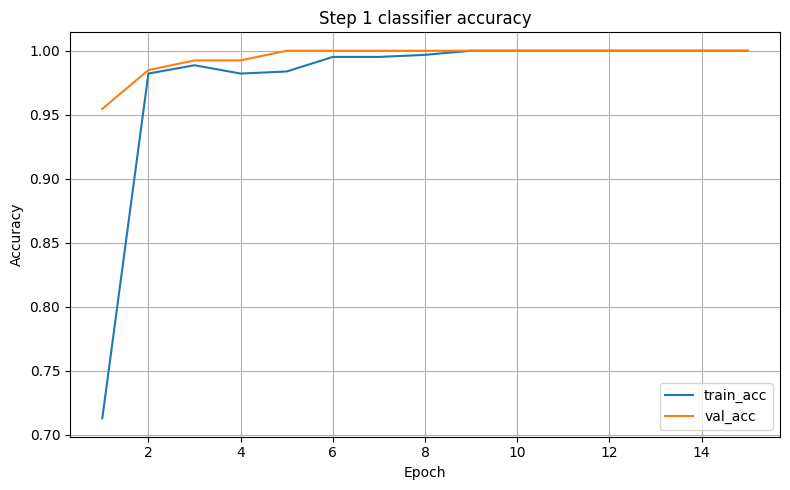

In [48]:
# Plot training curves.
history_df = pd.read_csv(OUTPUT_DIR / "training_history.csv")

plt.figure(figsize=(8, 5))
plt.plot(history_df.index + 1, history_df["train_acc"], label="train_acc")
plt.plot(history_df.index + 1, history_df["val_acc"], label="val_acc")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Step 1 classifier accuracy")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "accuracy_curve.png", dpi=150)
plt.show()

In [49]:
# Load the best saved model before test evaluation.
checkpoint = torch.load(best_path, map_location=device)
model = build_model(len(checkpoint["class_names"]), use_pretrained=False).to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded best model from:", best_path)
print("Best validation accuracy:", checkpoint.get("best_val_acc"))

Loaded best model from: ../outputs/image_classifier/best_resnet18_step1_classifier.pt
Best validation accuracy: 1.0


              precision    recall  f1-score   support

       Atlas       0.92      1.00      0.96        24
      Square       1.00      0.96      0.98        49
     Protein       1.00      1.00      1.00        30
       Other       1.00      1.00      1.00        30

    accuracy                           0.98       133
   macro avg       0.98      0.99      0.98       133
weighted avg       0.99      0.98      0.99       133



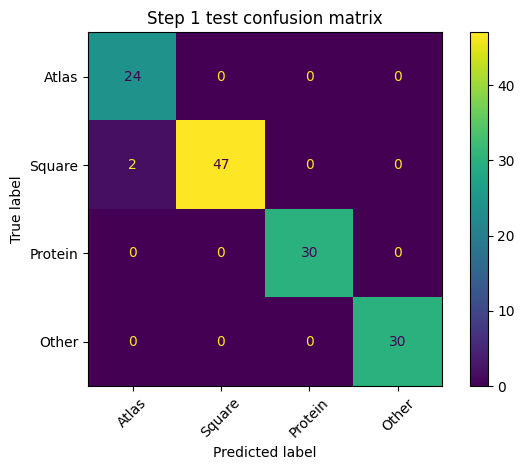

,path,true_label,pred_label,confidence,prob_Atlas,prob_Square,prob_Protein,prob_Other
0,../data/Other_All/24297-ERSytoBleed__cdp2bioac...,Other,Other,0.943052,0.026265,0.011164,0.019519,0.943052
1,../data/Other_All/24297-ERSytoBleed__cdp2bioac...,Other,Other,0.977632,0.009484,0.003079,0.009804,0.977632
2,../data/Square_All/GridSquare_20260317_210856.jpg,Square,Square,0.961604,0.013232,0.961604,0.017142,0.008023
3,../data/Atlas_All/atlas-5-ice very good.jpg,Atlas,Atlas,0.779479,0.779479,0.106535,0.083046,0.030939
4,../data/Protein_All/000573533776557681770_Foil...,Protein,Protein,0.895354,0.052773,0.023692,0.895354,0.028180


In [50]:
@torch.no_grad()
def predict_dataframe(model, loader):
    model.eval()
    rows = []

    for images, labels, paths in loader:
        images = images.to(device)
        logits = model(images)
        probs = torch.softmax(logits, dim=1).cpu().numpy()
        pred_idxs = probs.argmax(axis=1)

        for path, true_idx, pred_idx, prob_row in zip(paths, labels.numpy(), pred_idxs, probs):
            rows.append({
                "path": path,
                "true_label": IDX_TO_CLASS[int(true_idx)],
                "pred_label": IDX_TO_CLASS[int(pred_idx)],
                "confidence": float(prob_row[pred_idx]),
                **{f"prob_{CLASS_NAMES[i]}": float(prob_row[i]) for i in range(len(CLASS_NAMES))}
            })

    return pd.DataFrame(rows)


test_pred_df = predict_dataframe(model, test_loader)
test_pred_df.to_csv(OUTPUT_DIR / "test_predictions.csv", index=False)

print(classification_report(
    test_pred_df["true_label"],
    test_pred_df["pred_label"],
    labels=CLASS_NAMES,
    zero_division=0,
))

cm = confusion_matrix(
    test_pred_df["true_label"],
    test_pred_df["pred_label"],
    labels=CLASS_NAMES,
)

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(xticks_rotation=45)
plt.title("Step 1 test confusion matrix")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix.png", dpi=150)
plt.show()

test_pred_df.head()

In [51]:
# Save misclassified examples for review.
wrong_df = test_pred_df[test_pred_df["true_label"] != test_pred_df["pred_label"]].copy()
wrong_df = wrong_df.sort_values("confidence", ascending=False)
wrong_df.to_csv(OUTPUT_DIR / "misclassified_examples.csv", index=False)

print("Number misclassified:", len(wrong_df))
wrong_df.head(20)

Number misclassified: 2


,path,true_label,pred_label,confidence,prob_Atlas,prob_Square,prob_Protein,prob_Other
86,../data/Square_All/GridSquare_20251212_115430.jpg,Square,Atlas,0.742502,0.742502,0.113918,0.019908,0.123672
71,../data/Square_All/GridSquare_20260113_115633.jpg,Square,Atlas,0.626847,0.626847,0.241851,0.035635,0.095666


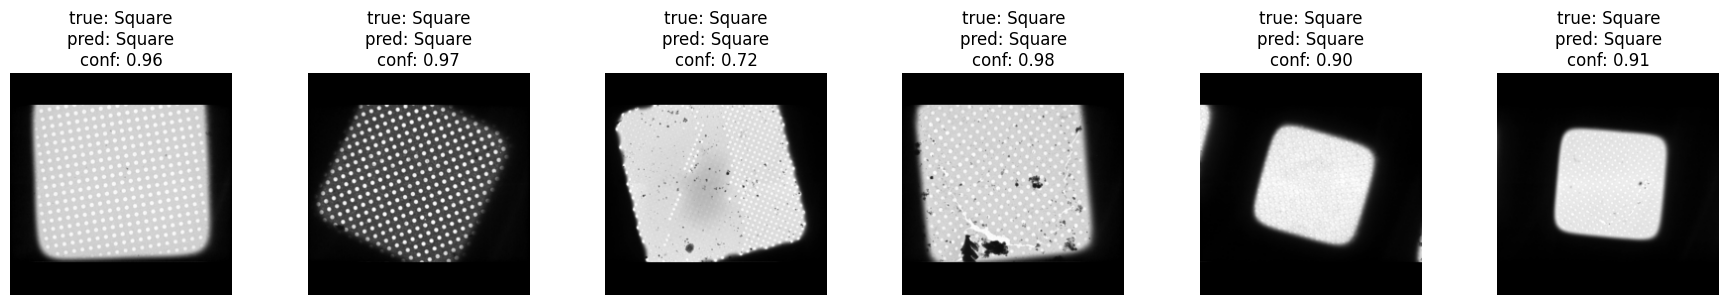

In [52]:
def show_prediction_examples(pred_df, n=8, mistakes_only=False):
    if mistakes_only:
        pred_df = pred_df[pred_df["true_label"] != pred_df["pred_label"]]

    if pred_df.empty:
        print("No examples to show.")
        return

    sample = pred_df.sample(n=min(n, len(pred_df)), random_state=SEED)
    n = len(sample)

    fig, axes = plt.subplots(1, n, figsize=(3*n, 3))
    if n == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, sample.iterrows()):
        img = SquarePadResize(IMAGE_SIZE)(read_cryo_pil(row["path"]))
        ax.imshow(img, cmap="gray")
        ax.set_title(
            f"true: {row['true_label']}\n"
            f"pred: {row['pred_label']}\n"
            f"conf: {row['confidence']:.2f}"
        )
        ax.axis("off")

    plt.tight_layout()
    plt.show()


show_prediction_examples(test_pred_df, n=6, mistakes_only=False)

In [53]:
def classify_image(path, model_path=best_path, confidence_threshold=0.60):
    """
    Classifies one image and returns routing information for the next pipeline.
    """
    checkpoint = torch.load(model_path, map_location=device)
    class_names = checkpoint["class_names"]

    inference_model = build_model(len(class_names), use_pretrained=False).to(device)
    inference_model.load_state_dict(checkpoint["model_state_dict"])
    inference_model.eval()

    img = read_cryo_pil(path)
    x = eval_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = inference_model(x)
        probs = torch.softmax(logits, dim=1)[0].cpu().numpy()

    pred_idx = int(np.argmax(probs))
    pred_label = class_names[pred_idx]
    confidence = float(probs[pred_idx])

    route_map = {
        "atlas": "send_to_step2_atlas_analyzer",
        "square": "send_to_step3_square_hole_analyzer",
        "protein": "send_to_step4_protein_micrograph_analyzer",
        "other": "return_error_or_request_different_image",
    }

    result = {
        "path": str(path),
        "predicted_label": pred_label,
        "confidence": confidence,
        "low_confidence_warning": confidence < confidence_threshold,
        "route": route_map.get(pred_label, "unknown_route"),
        "probabilities": {class_names[i]: float(probs[i]) for i in range(len(class_names))}
    }
    return result

In [54]:
# Optional: classify every image in a folder and save a CSV.
def classify_folder(folder_path, model_path=best_path, confidence_threshold=0.60):
    folder_path = Path(folder_path)
    paths = [
        p for p in folder_path.rglob("*")
        if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS
    ]

    rows = []
    for p in paths:
        try:
            result = classify_image(p, model_path=model_path, confidence_threshold=confidence_threshold)
            flat = {
                "path": result["path"],
                "predicted_label": result["predicted_label"],
                "confidence": result["confidence"],
                "low_confidence_warning": result["low_confidence_warning"],
                "route": result["route"],
            }
            for k, v in result["probabilities"].items():
                flat[f"prob_{k}"] = v
            rows.append(flat)
        except Exception as e:
            rows.append({
                "path": str(p),
                "predicted_label": "error",
                "confidence": 0.0,
                "low_confidence_warning": True,
                "route": "error",
                "error": repr(e),
            })

    out_df = pd.DataFrame(rows)
    return out_df


In [55]:
# ipynb specific, skip hidden folder from pynb auto save checkpoints
def classify_folder(folder_path, model_path=best_path, confidence_threshold=0.60):
    folder_path = Path(folder_path)

    def is_hidden_or_checkpoint(path):
        """
        Skip actual hidden files/folders like .ipynb_checkpoints,
        but do NOT skip normal relative path parts like '..'.
        """
        for part in path.parts:
            if part in [".", ".."]:
                continue
            if part.startswith("."):
                return True
        return False

    paths = [
        p for p in folder_path.rglob("*")
        if (
            p.is_file()
            and p.suffix.lower() in IMAGE_EXTENSIONS
            and not is_hidden_or_checkpoint(p)
        )
    ]

    paths = sorted(paths)

    print(f"Found {len(paths)} valid image files to classify.")

    rows = []

    for p in paths:
        print(p)
        try:
            result = classify_image(
                p,
                model_path=model_path,
                confidence_threshold=confidence_threshold
            )

            flat = {
                "path": result["path"],
                "predicted_label": result["predicted_label"],
                "confidence": result["confidence"],
                "low_confidence_warning": result["low_confidence_warning"],
                "route": result["route"],
            }

            for k, v in result["probabilities"].items():
                flat[f"prob_{k}"] = v

            rows.append(flat)

        except Exception as e:
            rows.append({
                "path": str(p),
                "predicted_label": "error",
                "confidence": 0.0,
                "low_confidence_warning": True,
                "route": "error",
                "error": repr(e),
            })

    out_df = pd.DataFrame(rows)
    return out_df

In [56]:
result = classify_folder("../new_images")

result

Found 24 valid image files to classify.
../new_images/001110821028799902949_FoilHole_30852272_Data_30766976_8_20250830_202337_fractions_patch_aligned_a9b95ee7.jpg
../new_images/003272864364844243685_FoilHole_30855826_Data_30766976_1_20250830_224819_fractions_patch_aligned_doseweighted_3cab1d1d.jpg
../new_images/004578801954506713417_FoilHole_30840803_Data_30766979_3_20250830_120538_fractions_patch_aligned_doseweighted_1a231680.jpg
../new_images/007213790768756637715_FoilHole_30774979_Data_30766976_4_20250830_043939_fractions_patch_aligned_fa8f7af2.jpg
../new_images/009050538682594227066_FoilHole_30840921_Data_30766979_17_20250830_121456_fractions_patch_aligned_0b68b580.jpg
../new_images/015385958141955723266_FoilHole_30846923_Data_30766979_47_20250830_170951_fractions_patch_aligned_14fc6e5a.jpg
../new_images/015991075542220381623_FoilHole_30858416_Data_30766979_27_20250831_002410_fractions_patch_aligned_d0f4c5eb.jpg
../new_images/Atlas_Grid3.jpg
../new_images/Atlas_test.jpg
../new_imag

,path,predicted_label,confidence,low_confidence_warning,route,prob_Atlas,prob_Square,prob_Protein,prob_Other
0,../new_images/001110821028799902949_FoilHole_3...,Protein,0.969378,False,unknown_route,0.018052,0.008434,0.969378,0.004136
1,../new_images/003272864364844243685_FoilHole_3...,Protein,0.955640,False,unknown_route,0.026709,0.008685,0.955640,0.008965
2,../new_images/004578801954506713417_FoilHole_3...,Protein,0.983291,False,unknown_route,0.006892,0.006396,0.983291,0.003421
3,../new_images/007213790768756637715_FoilHole_3...,Protein,0.955448,False,unknown_route,0.023878,0.013908,0.955448,0.006767
4,../new_images/009050538682594227066_FoilHole_3...,Protein,0.984378,False,unknown_route,0.009220,0.003897,0.984378,0.002506
5,../new_images/015385958141955723266_FoilHole_3...,Protein,0.925663,False,unknown_route,0.032148,0.025899,0.925663,0.016290
6,../new_images/015991075542220381623_FoilHole_3...,Protein,0.980263,False,unknown_route,0.014515,0.002951,0.980263,0.002271
7,../new_images/Atlas_Grid3.jpg,Atlas,0.966941,False,unknown_route,0.966941,0.006601,0.015492,0.010966
8,../new_images/Atlas_test.jpg,Atlas,0.990851,False,unknown_route,0.990851,0.002230,0.001651,0.005268
9,../new_images/GridSquare_20260110_161950.jpg,Square,0.969554,False,unknown_route,0.013582,0.969554,0.010883,0.005982
